In [22]:
from langgraph.graph import StateGraph,START,END
from langchain_mistralai import ChatMistralAI
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from typing import TypedDict
from rich import print


In [23]:
load_dotenv()

True

In [24]:
# LLM - model 
llm = ChatMistralAI(model='ministral-3b-2512')

In [ ]:
class BlogState(TypedDict):

    topic: str
    outline:str
    content:str
    rating:str

In [26]:
def create_outline(state: BlogState)->BlogState:
    # fetch the topic 
    topic = state['topic']

    # create a prompt 
    prompt = f"Generate the Outline for a blog on give topic - {topic}"

    # llm call gen outline

    response = llm.invoke(prompt)

    # update outline in state
    state['outline'] = response.content

    return state

In [27]:
def create_blog(state: BlogState)-> BlogState:
    # fetch title and outline
    title = state['topic']
    outline = state['outline']

    # prompt
    prompt = f"write the detailed blog on the topic -{title}.\n Using the following outline \n {outline}"

    # generate the responce 
    responce = llm.invoke(prompt).content

    # update the state 
    state['content'] = responce

    return state

In [36]:
def evaluate_blog(state: BlogState)->BlogState:

    # fetch all data from state
    topic = state['topic']
    outline = state['outline']
    content = state['content']

    # create the Evaluate prompt
    prompt = f""" 
you are expert content editor and system reviewer
Evaluate the generated blog post based on the following criteria:

1. Topic: {topic}
2. Planning Outline: {outline}
3. Generated content: {content}

 Tasks:
    - Rate the generated blog on a scale of 1 to 10 based on how well it followed the outline and addressed the topic. Provide brief reasoning.
    - Rate the AI generation system (us) on a scale of 1 to 10 for structural coherence and flow between the outline phase and writing phase.
    - Prescribe the AI generation blog on to rate on ['begginer', 'intermidiate','Advanced'] it followed on the blog content
    """
    # generate answer by llm
    responce = llm.invoke(prompt)

    state['rating'] = responce.content

    return state

    

In [ ]:
# create graph
graph = StateGraph(BlogState)

# add nodes in the graph
graph.add_node('create_outline',create_outline)
graph.add_node('create_blog',create_blog)
graph.add_node('evaluate_blog',evaluate_blog)

# add edges in the graph
graph.add_edge(START,'create_outline')
graph.add_edge('create_outline','create_blog')
graph.add_edge('create_blog','evaluate_blog')
graph.add_edge('evaluate_blog',END)

In [29]:
workflow = graph.compile()

In [30]:
initial_state = {'topic':'Rise of AI in India'}

final_state = workflow.invoke(initial_state)

In [33]:
print(final_state['topic'])

Rise of AI in India

In [34]:
print(final_state['outline'])

Here’s a well-structured **outline** for a blog titled:

---
# **"The Rise of AI in India: Opportunities, Challenges, and the Future"**

---

## **1. Introduction**
   - Brief overview of AI’s global impact and its growing significance in India.
   - Why AI is a game-changer for India’s economy, industries, and society.
   - Key statistics (e.g., India’s AI market size, government initiatives like **National AI Strategy 2018** and 
**Digital India**).
   - Thesis statement: AI is transforming India but also presents challenges that must be addressed for sustainable
growth.

---

## **2. AI in India: Current Landscape and Growth Drivers**
   - **Government Initiatives & Policies**
     - **National AI Strategy (2018)** – Objectives, key players (NITI Aayog, startups, corporates).
     - **Digital India, Skill India, and AI for All** – How these programs foster AI adoption.
     - **Startups & Ecosystem** – Key players (Tata, Infosys, Wipro, startups like **AI4India, DataRobot India**).
   - **Key Sectors Driven by AI**
     1. **Healthcare** – AI in diagnostics, telemedicine (e.g., **AI4Health, Apollo Hospitals’ AI initiatives**).
     2. **Education** – Personalized learning, AI tutors (e.g., **Byju’s, Vedantu**).
     3. **Finance & Banking** – Fraud detection, loan approvals (e.g., **HDFC Bank’s AI models, Paytm’s AI 
chatbots**).
     4. **Smart Cities & Infrastructure** – Traffic management, waste disposal (e.g., **Mumbai’s AI-driven smart 
city projects**).
     5. **Retail & E-commerce** – Recommendation engines, supply chain optimization (e.g., **Amazon India, 
Flipkart’s AI tools**).
     6. **Defense & Security** – AI in cybersecurity, surveillance (e.g., **DRDO’s AI projects**).
   - **Data Availability & Infrastructure**
     - Role of **data centers, cloud computing (AWS, Google Cloud in India), and high-speed internet**.
     - Challenges in data privacy and security.

---

## **3. AI in India: Opportunities for the Future**
   - **Economic Growth & Job Creation**
     - AI-driven automation vs. job displacement vs. new AI-related roles (e.g., **AI engineers, data 
scientists**).
     - Potential for **India to become a global AI hub** (like Silicon Valley but in Asia).
   - **Social Impact & Inclusivity**
     - AI for **rural development** (e.g., **AI-powered agriculture, financial inclusion**).
     - Accessibility in **education, healthcare, and public services**.
   - **Global Competitiveness**
     - India’s potential to **leverage AI for exports** (e.g., AI-driven manufacturing, healthcare exports).
     - Collaboration with **US, EU, and Asia-Pacific nations** in AI research.

---

## **4. Challenges & Ethical Concerns**
   - **Data Privacy & Security Risks**
     - **GDPR vs. Indian laws (Data Protection Bill, 2021)** – How India compares globally.
     - Risks of **data breaches, deepfake misuse, and surveillance abuses**.
   - **Skill Gap & Workforce Readiness**
     - Lack of **AI-trained professionals** compared to global standards.
     - Need for **upskilling programs (NITI Aayog’s AI training initiatives)**.
   - **Bias & Fairness in AI**
     - **Algorithmic bias** in hiring, lending, and policing (e.g., **AI-driven recruitment bias**).
     - Ensuring **diverse and inclusive AI models**.
   - **Regulatory & Policy Gaps**
     - Need for **stronger AI ethics guidelines** (similar to EU’s AI Act).
     - Balancing **innovation with safety** in critical sectors.

---

## **5. Case Studies: Success Stories & Failures**
   - **Success Stories**
     - **Healthcare:** **AI diagnostics at Apollo Hospitals** (reducing misdiagnosis rates).
     - **Education:** **Byju’s AI-powered learning platform** (reaching millions in India).
     - **Finance:** **HDFC Bank’s AI fraud detection** (saving billions in losses).
   - **Challenges & Lessons Learned**
     - **Failed AI projects in India** (e.g., **AI startups shutting down due to lack of funding**).
     - **Over-reliance on foreign models** vs. **local AI

In [32]:
print(final_state['content'])

# **The Rise of AI in India: Opportunities, Challenges, and the Future**

## **Introduction**

Artificial Intelligence (AI) is no longer a futuristic concept—it’s reshaping industries, economies, and daily life
globally. In India, AI is experiencing a rapid surge, driven by government initiatives, technological advancements,
and a burgeoning startup ecosystem. With a young, tech-savvy population and a booming digital economy, India is 
positioned to become one of the world’s leading AI hubs.

According to recent reports, the **AI market in India is projected to grow at a CAGR of 37%**, reaching **$25 
billion by 2026**. The **National AI Strategy (2018)**, launched by NITI Aayog, and initiatives like **Digital 
India, Skill India, and AI for All** are accelerating AI adoption across sectors. However, challenges such as 
**data privacy concerns, a skills gap, and ethical dilemmas** must be addressed for sustainable growth.

This blog explores **AI’s current landscape in India, its transformative opportunities, key challenges, and the 
future trajectory**—helping businesses, policymakers, and individuals navigate this evolving digital revolution.

---

## **2. AI in India: Current Landscape and Growth Drivers**

### **Government Initiatives & Policies**

India’s AI journey is heavily backed by **government-led policies**, creating a conducive environment for 
innovation:

- **National AI Strategy (2018)**:
  - Launched by **NITI Aayog**, this strategy aims to make India a **global AI leader** by 2030.
  - Key objectives:
    - **$1 trillion economy** by 2025.
    - **100,000 AI researchers** by 2025.
    - **$1 billion investment** in AI startups.
  - Key stakeholders: **Tech giants (Tata, Infosys, Wipro), startups (AI4India, DataRobot India), and academia 
(IITs, IIMs).**

- **Digital India & Skill India**:
  - **Digital India** promotes AI-driven governance, smart cities, and e-governance.
  - **Skill India** focuses on **AI upskilling**, with initiatives like **AI for All** and **NITI Aayog’s AI 
training programs**.

- **AI Startups & Ecosystem**:
  - **Tata Consultancy Services (TCS)** and **Infosys** are leading AI adoption in enterprises.
  - **AI4India** and **DataRobot India** are pushing AI-driven solutions.
  - **Incubators & Accelerators**: IIT incubators, **NASSCOM’s AI programs**, and **TechSpark** (by NITI Aayog) 
support AI startups.

### **Key Sectors Driven by AI**

AI is transforming multiple sectors in India:

| **Sector**       | **AI Applications** | **Key Examples** |
|------------------|---------------------|------------------|
| **Healthcare**   | Diagnostics, telemedicine | **AI4Health, Apollo Hospitals’ AI models** |
| **Education**    | Personalized learning | **Byju’s, Vedantu’s AI tutors** |
| **Finance**      | Fraud detection, loan approvals | **HDFC Bank’s AI models, Paytm’s chatbots** |
| **Smart Cities** | Traffic management, waste disposal | **Mumbai’s AI-driven smart city projects** |
| **Retail**       | Recommendation engines, supply chain | **Amazon India, Flipkart’s AI tools** |
| **Defense**      | Cybersecurity, surveillance | **DRDO’s AI projects** |

### **Data Availability & Infrastructure**

AI’s success depends on **data availability and infrastructure**:

- **Data Centers & Cloud Computing**:
  - **AWS, Google Cloud, and Azure** are expanding in India.
  - **Data centers in Mumbai, Bangalore, and Hyderabad** are growing.
- **Internet & Connectivity**:
  - **5G rollout** and **high-speed internet** are crucial for AI adoption.
- **Challenges**:
  - **Data privacy concerns** (e.g., **GDPR vs. Indian laws**).
  - **Lack of standardized AI regulations** in critical sectors.

---

## **3. AI in India: Opportunities for the Future**

### **Economic Growth & Job Creation**

AI is expected to **create millions of new jobs** while automating existing roles:

- **AI-Driven Automation vs. Job Displacement**:
  - **Short-term**: Job losses in **routine tasks (customer service, data entry)**.


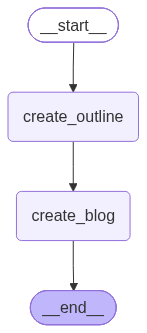

In [14]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())